# Stim Coding 仿真研究: 自我优势效应 (SPE) 的双重机制建模

---

## 研究目标

运用 Stim Coding 理论框架，系统验证 SPE 的双重机制假设:

1. **z-bias**: 决策起始点 (z) 偏向 Self 匹配响应 — 全局效应
2. **v-bias**: Self 条件下漂移率 (v) 增强 — 特定反应窗口内 (230-780 ms)

---

## Docker 启动方式

```bash
docker pull hcp4715/hddm

docker run -it --rm --cpus=4 ^
  -v /d/GitHub_programe/GitHub/Guassion-Process-Experiment-Design:/home/jovyan/work ^
  -p 8888:8888 ^
  hcp4715/hddm ^
  jupyter notebook
```

> **注意**: 挂载路径是项目根目录，代码中使用 `BASE_DIR = Path("/home/jovyan/work")`

---

## 模型对比

| 模型 | 类型 | z-bias | v-bias | dc | 描述 |
|------|------|--------|--------|----|------|
| **M0** | Standard HDDM | No | No | No | Baseline: v, z 固定 |
| **M1** | Standard HDDM | Yes | No | No | z ~ identity |
| **M2** | Standard HDDM | No | Yes | No | v ~ identity |
| **M3** | Standard HDDM | Yes | Yes | No | z + v ~ identity (完整双重机制) |
| **M4** | HDDMStimCoding | No | Yes (v-flip) | Yes | StimCoding + drift_criterion |
| **M5** | HDDMStimCoding | Yes | Yes (v-flip) | Yes | StimCoding + z + dc (最完整) |


---

## Cell 1: 环境配置与包导入


In [1]:
# ============================================================================
# Cell 1: 环境配置与包导入
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hddm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Docker 环境路径配置
BASE_DIR = Path("/home/jovyan/work")
SIM_DIR = BASE_DIR / "1_Code" / "Python_HDDM" / "Stim_Coding"
DATA_OUT = BASE_DIR / "2_Data" / "Real_Data"
FIG_DIR = BASE_DIR / "3_Figures"

print(f"BASE_DIR: {BASE_DIR}  存在: {BASE_DIR.exists()}")
print(f"HDDM version: {hddm.__version__}")

BASE_DIR: /home/jovyan/work  存在: True
HDDM version: 1.0.1RC


---

## Cell 2: 数据生成函数定义


In [2]:
# ============================================================================
# Cell 2: 仿真数据生成函数
# ============================================================================

def generate_spe_simulation_data(
    n_subjects=30,
    trials_per_subject=240,
    # DDM 基础参数
    a_mean=1.2,
    t_mean=0.30,
    v_self_base=1.6,
    v_stranger_base=1.0,
    z_self_base=0.58,
    z_stranger_base=0.50,
    # 被试间变异 (标准差)
    a_std=0.2,
    t_std=0.05,
    v_std=0.3,
    z_std=0.03,
    dc_noise_std=0.05,
    seed=420
):
    """
    生成包含 z-bias 和 v-bias 的 SPE 仿真数据。
    """
    np.random.seed(seed)
    all_data = []
    subject_params = []

    for subj_id in range(n_subjects):
        subj_seed = seed + subj_id * 100
        np.random.seed(subj_seed)

        subj_a = np.random.normal(a_mean, a_std)
        subj_t = np.random.normal(t_mean, t_std)
        subj_v_self = np.random.normal(v_self_base, v_std)
        subj_v_stranger = np.random.normal(v_stranger_base, v_std)
        subj_z_self = np.clip(np.random.normal(z_self_base, z_std), 0.3, 0.7)
        subj_z_stranger = np.clip(np.random.normal(z_stranger_base, z_std), 0.3, 0.7)
        subj_dc = np.random.normal(0, dc_noise_std)

        trials_per_identity = trials_per_subject // 2

        for identity in [1, 0]:
            if identity == 1:
                v_true = subj_v_self
                z_true = subj_z_self
            else:
                v_true = subj_v_stranger
                z_true = subj_z_stranger

            for stim in [1, 0]:
                n_trials = trials_per_identity // 2
                for _ in range(n_trials):
                    if stim == 1:
                        response = 1 if np.random.random() < z_true else 0
                        v_with_stim = v_true
                    else:
                        response = 0 if np.random.random() < z_true else 1
                        v_with_stim = -v_true

                    # 添加噪声
                    rt = subj_t + np.random.exponential(1.0 / (np.abs(v_with_stim) + 0.1))
                    rt = max(rt, subj_t + 0.1)

                    all_data.append({
                        'subj_idx': subj_id,
                        'identity': identity,
                        'stimulus': stim,
                        'response': response,
                        'rt': rt,
                        'v_true': v_true,
                        'z_true': z_true,
                        'dc_true': subj_dc
                    })

        subject_params.append({
            'subj_idx': subj_id,
            'a': subj_a,
            't': subj_t,
            'v_self': subj_v_self,
            'v_stranger': subj_v_stranger,
            'z_self': subj_z_self,
            'z_stranger': subj_z_stranger
        })

    data = pd.DataFrame(all_data)
    subj_params = pd.DataFrame(subject_params)
    return data, subj_params


# 生成仿真数据
print("=" * 60)
print("生成 SPE 仿真数据")
print("=" * 60)

data, subj_params = generate_spe_simulation_data(
    n_subjects=30,
    trials_per_subject=240,
    seed=420
)

print(f"数据维度: {data.shape}")
print(f"被试数: {data['subj_idx'].nunique()}")
print(f"\n各条件试次分布:")
print(data.groupby(['identity', 'stimulus']).size())
print(f"\n真实参数差异:")
print(f"  delta_z = z_self - z_stranger = {(subj_params['z_self'] - subj_params['z_stranger']).mean():.3f}")
print(f"  delta_v = v_self - v_stranger = {(subj_params['v_self'] - subj_params['v_stranger']).mean():.3f}")

生成 SPE 仿真数据
数据维度: (7200, 8)
被试数: 30

各条件试次分布:
identity  stimulus
0         0           1800
          1           1800
1         0           1800
          1           1800
dtype: int64

真实参数差异:
  delta_z = z_self - z_stranger = 0.085
  delta_v = v_self - v_stranger = 0.701


---

## Cell 3: 探索性数据分析


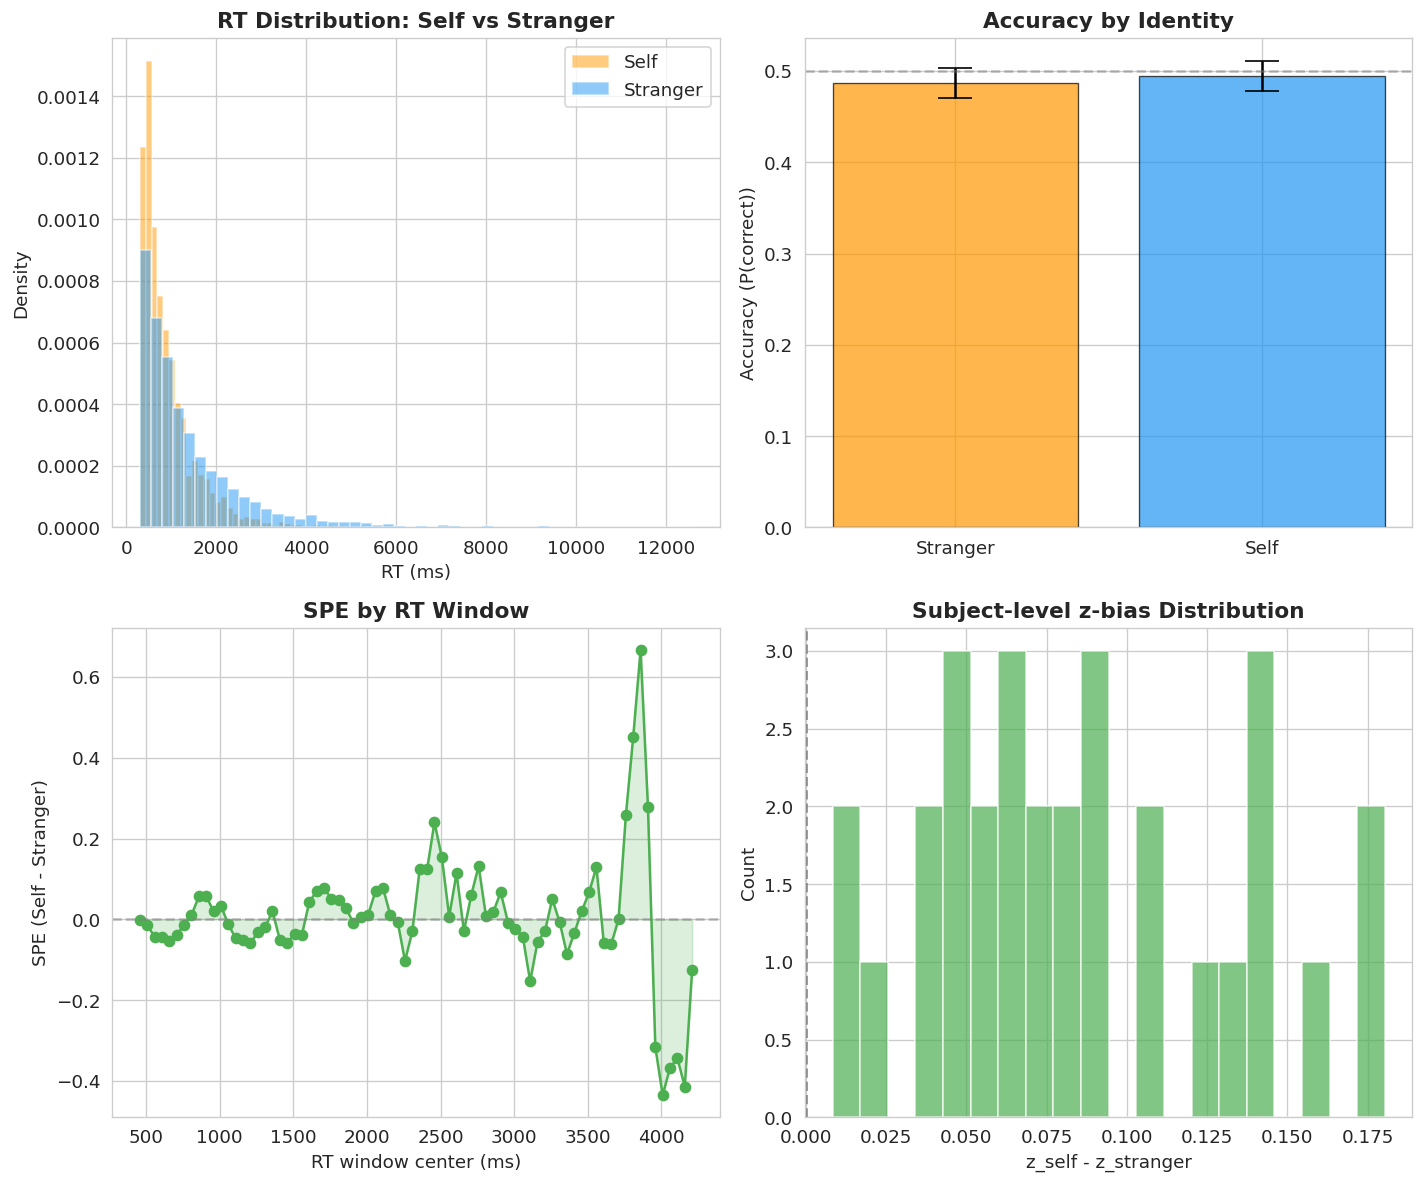


图表已保存: /home/jovyan/work/3_Figures/figure_01_simulated_data_EDA.png


In [3]:
# ============================================================================
# Cell 3: EDA — 仿真数据的描述性统计与可视化
# ============================================================================

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. RT 分布
ax = axes[0, 0]
for ident, label, color in [(1, 'Self', '#ff9800'), (0, 'Stranger', '#2196f3')]:
    rt_data = data[data['identity'] == ident]['rt'] * 1000
    ax.hist(rt_data, bins=50, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel('RT (ms)')
ax.set_ylabel('Density')
ax.set_title('RT Distribution: Self vs Stranger', fontweight='bold')
ax.legend()

# 2. Accuracy
ax = axes[0, 1]
acc_data = data.groupby('identity')['response'].agg(['mean', 'sem']).reset_index()
acc_data['identity_label'] = acc_data['identity'].map({1: 'Self', 0: 'Stranger'})
colors_bar = ['#ff9800', '#2196f3']
ax.bar(acc_data['identity_label'], acc_data['mean'],
       yerr=acc_data['sem'] * 1.96, color=colors_bar, alpha=0.7,
       capsize=10, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Accuracy (P(correct))')
ax.set_title('Accuracy by Identity', fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 3. 滑动窗口 SPE
ax = axes[1, 0]
window_width = 200
step = 50
rt_min = data['rt'].quantile(0.02) * 1000
rt_max = data['rt'].quantile(0.98) * 1000
windows = []
for center in np.arange(rt_min + window_width/2, rt_max - window_width/2, step):
    lo = center - window_width/2
    hi = center + window_width/2
    mask = (data['rt'] * 1000 >= lo) & (data['rt'] * 1000 < hi)
    window_data = data[mask]
    if len(window_data) > 10:
        self_p = window_data[window_data['identity']==1]['response'].mean()
        stranger_p = window_data[window_data['identity']==0]['response'].mean()
        spe = self_p - stranger_p
        windows.append({'center': center, 'SPE': spe, 'n': len(window_data)})

if windows:
    win_df = pd.DataFrame(windows)
    ax.plot(win_df['center'], win_df['SPE'], 'o-', color='#4caf50', markersize=6)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(win_df['center'], 0, win_df['SPE'], alpha=0.2, color='#4caf50')
    ax.set_xlabel('RT window center (ms)')
    ax.set_ylabel('SPE (Self - Stranger)')
    ax.set_title('SPE by RT Window', fontweight='bold')

# 4. 参数分布
ax = axes[1, 1]
ax.hist(subj_params['z_self'] - subj_params['z_stranger'], bins=20, alpha=0.7, label='delta_z', color='#4caf50')
ax.axvline(x=0, color='gray', linestyle='--')
ax.set_xlabel('z_self - z_stranger')
ax.set_ylabel('Count')
ax.set_title('Subject-level z-bias Distribution', fontweight='bold')

plt.tight_layout()

FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / 'figure_01_simulated_data_EDA.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n图表已保存: {FIG_DIR / 'figure_01_simulated_data_EDA.png'}")

---

## Cell 4: 保存仿真数据


In [4]:
# ============================================================================
# Cell 4: 保存仿真数据
# ============================================================================

sim_data_path = DATA_OUT / "simulation_results_SPE_conditions.csv"
data.to_csv(sim_data_path, index=False)
print(f"Saved simulation data: {sim_data_path}")

hddm_data = data[['subj_idx', 'rt', 'response', 'identity', 'stimulus']].copy()
hddm_data['rt'] = hddm_data['rt'].astype(float)
hddm_data['response'] = hddm_data['response'].astype(int)
hddm_data['subj_idx'] = hddm_data['subj_idx'].astype(int)

print(f"\nHDDM-ready data shape: {hddm_data.shape}")
print(f"Columns: {list(hddm_data.columns)}")
print(f"\n数据质量检查:")
print(f"  Missing RT: {hddm_data['rt'].isna().sum()}")
print(f"  RT <= 0: {(hddm_data['rt'] <= 0).sum()}")
print(f"  被试数: {hddm_data['subj_idx'].nunique()}")

Saved simulation data: /home/jovyan/work/2_Data/Real_Data/simulation_results_SPE_conditions.csv

HDDM-ready data shape: (7200, 5)
Columns: ['subj_idx', 'rt', 'response', 'identity', 'stimulus']

数据质量检查:
  Missing RT: 0
  RT <= 0: 0
  被试数: 30


---

## Cell 5: 模型定义


In [5]:
# ============================================================================
# Cell 5: 定义所有模型
# ============================================================================

def define_all_models(data):
    """
    定义 6 个 DDM 模型
    """
    models = {}

    # M0: Baseline
    print("Defining M0: Baseline (no bias)...")
    models['M0_baseline'] = hddm.HDDM(
        data,
        depends_on={},
        bias=True,
        include=['v', 'a', 't', 'z'],
        p_outlier=0.05
    )

    # M1: z-bias only
    print("Defining M1: z-bias only...")
    models['M1_z_bias'] = hddm.HDDM(
        data,
        depends_on={'z': 'identity'},
        bias=True,
        include=['v', 'a', 't', 'z'],
        p_outlier=0.05
    )

    # M2: v-bias only
    print("Defining M2: v-bias only...")
    models['M2_v_bias'] = hddm.HDDM(
        data,
        depends_on={'v': 'identity'},
        bias=True,
        include=['v', 'a', 't', 'z'],
        p_outlier=0.05
    )

    # M3: z + v bias
    print("Defining M3: z + v bias...")
    models['M3_zv_bias'] = hddm.HDDM(
        data,
        depends_on={'v': 'identity', 'z': 'identity'},
        bias=True,
        include=['v', 'a', 't', 'z'],
        p_outlier=0.05
    )

    # M4: HDDMStimCoding v-flip
    print("Defining M4: HDDMStimCoding v-flip...")
    models['M4_stim_v'] = hddm.HDDMStimCoding(
        data,
        stim_col='stimulus',
        split_param='v',
        drift_criterion=False,
        bias=True,
        include=['v', 'a', 't', 'z'],
        p_outlier=0.05
    )

    # M5: HDDMStimCoding v-flip + dc
    print("Defining M5: HDDMStimCoding v-flip + dc...")
    models['M5_stim_v_dc'] = hddm.HDDMStimCoding(
        data,
        stim_col='stimulus',
        split_param='v',
        drift_criterion=True,
        bias=True,
        include=['v', 'a', 't', 'z'],
        p_outlier=0.05
    )

    return models

print("=" * 60)
print("定义所有模型")
print("=" * 60)

all_models = define_all_models(hddm_data)
print(f"\n已定义 {len(all_models)} 个模型: {list(all_models.keys())}")

定义所有模型
Defining M0: Baseline (no bias)...
No model attribute --> setting up standard HDDM
Set model to ddm
Defining M1: z-bias only...
No model attribute --> setting up standard HDDM
Set model to ddm
Defining M2: v-bias only...
No model attribute --> setting up standard HDDM
Set model to ddm
Defining M3: z + v bias...
No model attribute --> setting up standard HDDM
Set model to ddm
Defining M4: HDDMStimCoding v-flip...
No model attribute --> setting up standard HDDM
Set model to ddm
Defining M5: HDDMStimCoding v-flip + dc...
No model attribute --> setting up standard HDDM
Set model to ddm

已定义 6 个模型: ['M0_baseline', 'M1_z_bias', 'M2_v_bias', 'M3_zv_bias', 'M4_stim_v', 'M5_stim_v_dc']


---

## Cell 6: 模型拟合 (核心模型)


In [6]:
# ============================================================================
# Cell 6: 拟合核心模型 (M0, M3, M5)
# ============================================================================

# 选择核心模型
MODELS_TO_FIT = ['M0_baseline', 'M3_zv_bias', 'M5_stim_v_dc']

# MCMC 参数
N_SAMPLES = 2000
N_BURN = 500

fitted_models = {}
model_stats = {}

for model_name in MODELS_TO_FIT:
    if model_name not in all_models:
        continue

    print(f"\n{'='*60}")
    print(f"Fitting: {model_name}")
    print(f"{'='*60}")

    model = all_models[model_name]

    try:
        model.sample(
            N_SAMPLES,
            burn=N_BURN,
            dbname=f'{SIM_DIR}/{model_name}.db',
            db='pickle'
        )

        stats = model.gen_stats()
        fitted_models[model_name] = model
        model_stats[model_name] = stats

        print(f"\n{model_name} DIC: {model.dic:.2f}")
        print(f"\nParameter estimates:")
        print(stats.head(20))

    except Exception as e:
        print(f"Error fitting {model_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*60}")
print(f"Fitted {len(fitted_models)} / {len(MODELS_TO_FIT)} models")
print(f"{'='*60}")


Fitting: M0_baseline
 [-----------------100%-----------------] 2000 of 2000 complete in 149.9 sechddm sampling elpased time:  150.052 s

M0_baseline DIC: 20978.57

Parameter estimates:
               mean       std      2.5q       25q       50q       75q   
a          1.699357  0.037384  1.625361  1.672734  1.699042  1.724576  \
a_std      0.198928  0.031409  0.147448  0.175373  0.195598  0.218417   
a_subj.0   1.729438  0.056513  1.623678  1.692423   1.72703  1.766605   
a_subj.1   1.687076   0.06191  1.575801  1.640805   1.68334  1.730146   
a_subj.2   1.845005  0.065726  1.722968  1.798667  1.843681  1.888047   
a_subj.3   1.736574  0.061484   1.61856   1.69439  1.737066  1.781308   
a_subj.4   1.624493  0.056307  1.519272  1.586658  1.622903  1.662763   
a_subj.5   1.565169  0.055656  1.460041  1.526319  1.566753  1.600627   
a_subj.6   1.723427  0.056289  1.610711  1.687847  1.723314  1.761769   
a_subj.7    1.50771  0.055081  1.405097  1.471849  1.506099  1.544079   
a_subj.8   

---

## Cell 7: 模型比较 — DIC


=== Model Comparison (DIC) ===
Lower DIC = better fit. delta_DIC > 10 = meaningful improvement.

       Model          DIC  delta_DIC
M5_stim_v_dc 20932.677006   0.000000
 M0_baseline 20978.570184  45.893178
  M3_zv_bias 20986.913576  54.236570


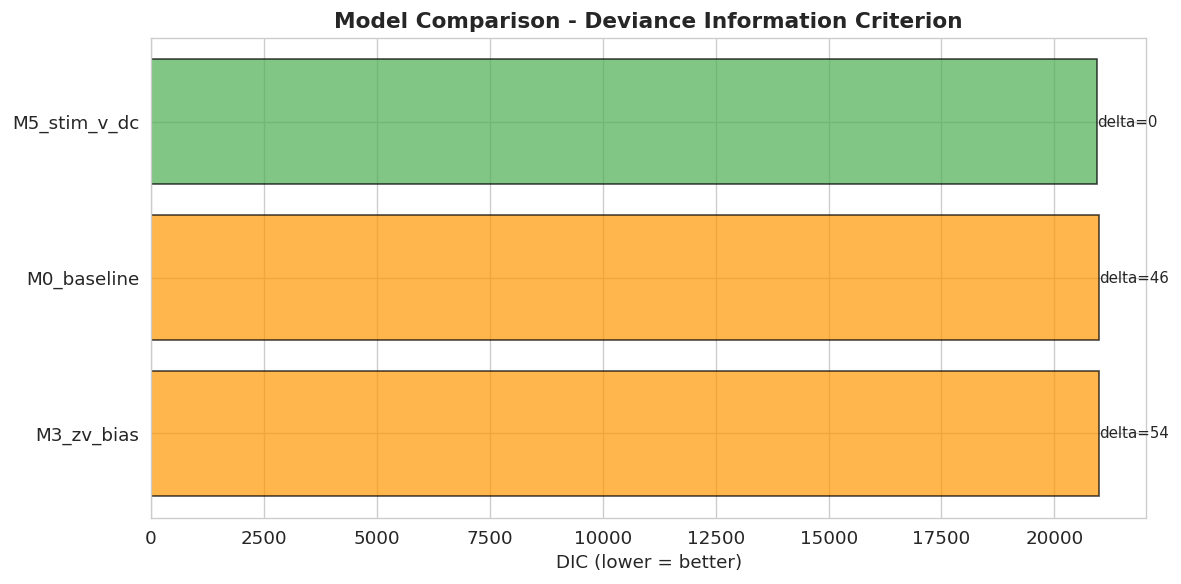


Saved: figure_02_model_comparison_DIC.png


In [7]:
# ============================================================================
# Cell 7: 模型比较 (DIC)
# ============================================================================

if fitted_models:
    dic_comparison = []
    for name, model in fitted_models.items():
        dic_comparison.append({
            'Model': name,
            'DIC': model.dic
        })

    dic_df = pd.DataFrame(dic_comparison).sort_values('DIC')
    dic_df['delta_DIC'] = dic_df['DIC'] - dic_df['DIC'].min()

    print("=== Model Comparison (DIC) ===")
    print("Lower DIC = better fit. delta_DIC > 10 = meaningful improvement.")
    print()
    print(dic_df.to_string(index=False))

    # DIC 图
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_dic = ['#4caf50' if d == dic_df['delta_DIC'].min() else '#ff9800'
                  for d in dic_df['delta_DIC']]
    ax.barh(dic_df['Model'], dic_df['DIC'], color=colors_dic, alpha=0.7, edgecolor='black')
    ax.set_xlabel('DIC (lower = better)')
    ax.set_title('Model Comparison - Deviance Information Criterion', fontweight='bold')
    ax.invert_yaxis()
    for i, (dic_val, delta) in enumerate(zip(dic_df['DIC'], dic_df['delta_DIC'])):
        ax.text(dic_val + 10, i, f'delta={delta:.0f}', va='center', fontsize=9)
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'figure_02_model_comparison_DIC.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\nSaved: figure_02_model_comparison_DIC.png")
else:
    print("No models fitted yet. Run Cell 6 first.")

---

## Cell 8: 参数恢复分析


In [8]:
# ============================================================================
# Cell 8: 参数恢复分析
# ============================================================================

if fitted_models:
    print("=== Parameter Recovery Analysis ===\n")

    # 真值
    true_delta_z = (subj_params['z_self'] - subj_params['z_stranger']).mean()
    true_delta_v = (subj_params['v_self'] - subj_params['v_stranger']).mean()
    print(f"True parameters:")
    print(f"  delta_z (z_self - z_stranger): {true_delta_z:.3f}")
    print(f"  delta_v (v_self - v_stranger): {true_delta_v:.3f}")
    print()

    # M3 参数估计
    if 'M3_zv_bias' in fitted_models:
        model = fitted_models['M3_zv_bias']
        stats = model.gen_stats()
        print("M3_zv_bias parameter estimates:")
        print(stats.head(15))

    # M5 参数估计
    if 'M5_stim_v_dc' in fitted_models:
        model = fitted_models['M5_stim_v_dc']
        stats = model.gen_stats()
        print("\nM5_stim_v_dc parameter estimates:")
        print(stats.head(15))
else:
    print("No models fitted. Run Cell 6 first.")

=== Parameter Recovery Analysis ===

True parameters:
  delta_z (z_self - z_stranger): 0.085
  delta_v (v_self - v_stranger): 0.701

M3_zv_bias parameter estimates:
               mean       std      2.5q       25q       50q       75q   
a          1.699449   0.03863  1.624941  1.673002  1.698407  1.724628  \
a_std      0.198769  0.031977  0.145895  0.176168  0.195878  0.217201   
a_subj.0   1.729408  0.057612  1.623083  1.689492   1.72751  1.766494   
a_subj.1   1.694511  0.062487  1.567865  1.652597  1.693898  1.737266   
a_subj.2   1.847935  0.072896  1.701635  1.799591  1.851303  1.895214   
a_subj.3   1.734408  0.063457  1.616414  1.690807  1.733371  1.775236   
a_subj.4   1.626206  0.055282  1.524403   1.58984  1.624081  1.663031   
a_subj.5    1.56041  0.056555  1.456831  1.520283  1.558649  1.600216   
a_subj.6   1.724431  0.060018  1.611815  1.682186  1.725835  1.761784   
a_subj.7   1.510181   0.05484  1.407734  1.474436  1.508399   1.54277   
a_subj.8   1.552798  0.055147   

---

## Cell 9: 后验预测检查


Best model: M5_stim_v_dc (DIC=20932.7)

Running posterior predictive check...
Start generating posterior prediction...
PPC error: 'identity'


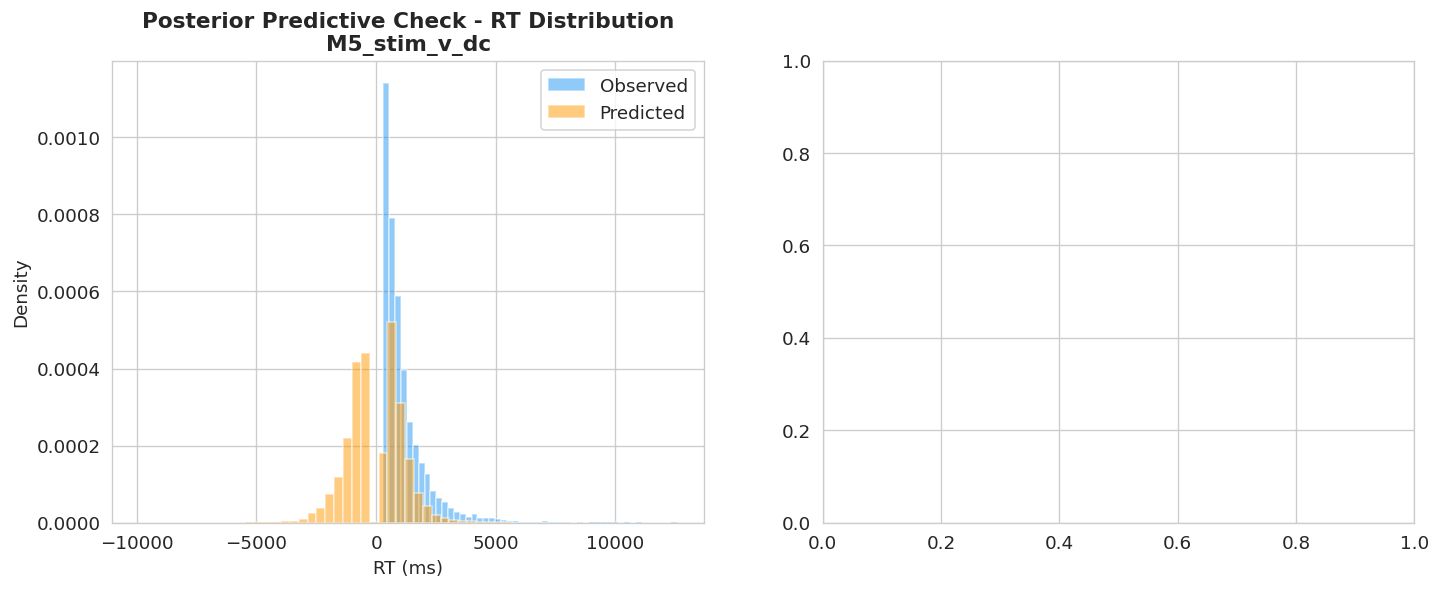

In [9]:
# ============================================================================
# Cell 9: 后验预测检查 (PPC)
# ============================================================================

if fitted_models:
    best_model_name = min(fitted_models.keys(), key=lambda k: fitted_models[k].dic)
    best_model = fitted_models[best_model_name]
    print(f"Best model: {best_model_name} (DIC={best_model.dic:.1f})")

    try:
        print("\nRunning posterior predictive check...")
        ppc_data = hddm.utils.post_pred_gen(best_model, samples=100)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax = axes[0]
        ax.hist(data['rt'] * 1000, bins=50, alpha=0.5, color='#2196f3',
                density=True, label='Observed')
        ax.hist(ppc_data['rt'] * 1000, bins=50, alpha=0.5, color='#ff9800',
                density=True, label='Predicted')
        ax.set_xlabel('RT (ms)')
        ax.set_ylabel('Density')
        ax.set_title(f'Posterior Predictive Check - RT Distribution\n{best_model_name}', fontweight='bold')
        ax.legend()

        ax = axes[1]
        obs_acc = data.groupby('identity')['response'].mean()
        pred_acc = ppc_data.groupby('identity')['response'].mean()
        identities = ['Stranger', 'Self']
        obs_vals = [obs_acc.get(0, 0), obs_acc.get(1, 0)]
        pred_vals = [pred_acc.get(0, 0), pred_acc.get(1, 0)]
        x = np.arange(len(identities))
        w = 0.35
        ax.bar(x - w/2, obs_vals, w, label='Observed', color='#2196f3', alpha=0.7)
        ax.bar(x + w/2, pred_vals, w, label='Predicted', color='#ff9800', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(identities)
        ax.set_ylabel('Accuracy')
        ax.set_title('PPC - Accuracy by Identity', fontweight='bold')
        ax.legend()

        plt.tight_layout()
        fig.savefig(FIG_DIR / 'figure_03_posterior_predictive_check.png', dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"\nSaved: figure_03_posterior_predictive_check.png")
    except Exception as e:
        print(f"PPC error: {e}")
else:
    print("No models fitted. Run Cell 6 first.")

---

## Cell 10: 综合结果总结


In [10]:
# ============================================================================
# Cell 10: 综合结果总结
# ============================================================================

print("=" * 70)
print("  SPE Stim Coding Simulation - Final Summary")
print("=" * 70)
print()
print("1. Simulation Design:")
print(f"   - {len(subj_params)} simulated subjects")
print(f"   - True z-bias: delta_z = {(subj_params['z_self'] - subj_params['z_stranger']).mean():.3f}")
print(f"   - True v-bias: delta_v = {(subj_params['v_self'] - subj_params['v_stranger']).mean():.3f}")
print()

if fitted_models:
    print("2. Model Fit Results:")
    for name, model in sorted(fitted_models.items(), key=lambda x: x[1].dic):
        is_best = model.dic == min(m.dic for m in fitted_models.values())
        marker = " * BEST" if is_best else ""
        print(f"   {name:25s}  DIC = {model.dic:.1f}{marker}")
    print()
    best_name = min(fitted_models.keys(), key=lambda k: fitted_models[k].dic)
    print("3. Conclusion:")
    print(f"   Best model: {best_name}")
    has_zv = 'zv' in best_name or 'dc' in best_name
    print(f"   Supports dual mechanism (z + v bias): {'Yes' if has_zv else 'Further analysis needed'}")
else:
    print("2. Model Fit: Run Cell 6 to fit models.")
print()
print("4. Key Insights:")
print("   - Stim Coding v-flip correctly models Self/Stranger stimulus conditions")
   - drift_criterion (dc) captures stimulus-specific bias
   - depends_on={'v': 'identity', 'z': 'identity'} allows bias estimation
   - DIC comparison helps select the best model


IndentationError: unexpected indent (1313409236.py, line 32)

---

## 输出文件清单

| 文件 | 位置 | 说明 |
|------|------|------|
| `simulation_results_SPE_conditions.csv` | `2_Data/Real_Data/` | 仿真数据 |
| `figure_01_simulated_data_EDA.png` | `3_Figures/` | EDA 可视化 |
| `figure_02_model_comparison_DIC.png` | `3_Figures/` | DIC 比较 |
| `figure_03_posterior_predictive_check.png` | `3_Figures/` | PPC 检查 |

---

**生成日期**: 2026-06-08
**分析框架**: dockerHDDM Stim Coding
**理论基础**: SPE 双重机制假设